INTEGRATED PEER LEARNING + FORGETTING MODEL SIMULATION

Comparing 4 scenarios:
  1. Baseline (No peer learning, no forgetting)
  2. Peer Learning Only
  3. Forgetting Only
  4. Peer + Forgetting (Full Integration)
--------------------------------------------------------------------------------


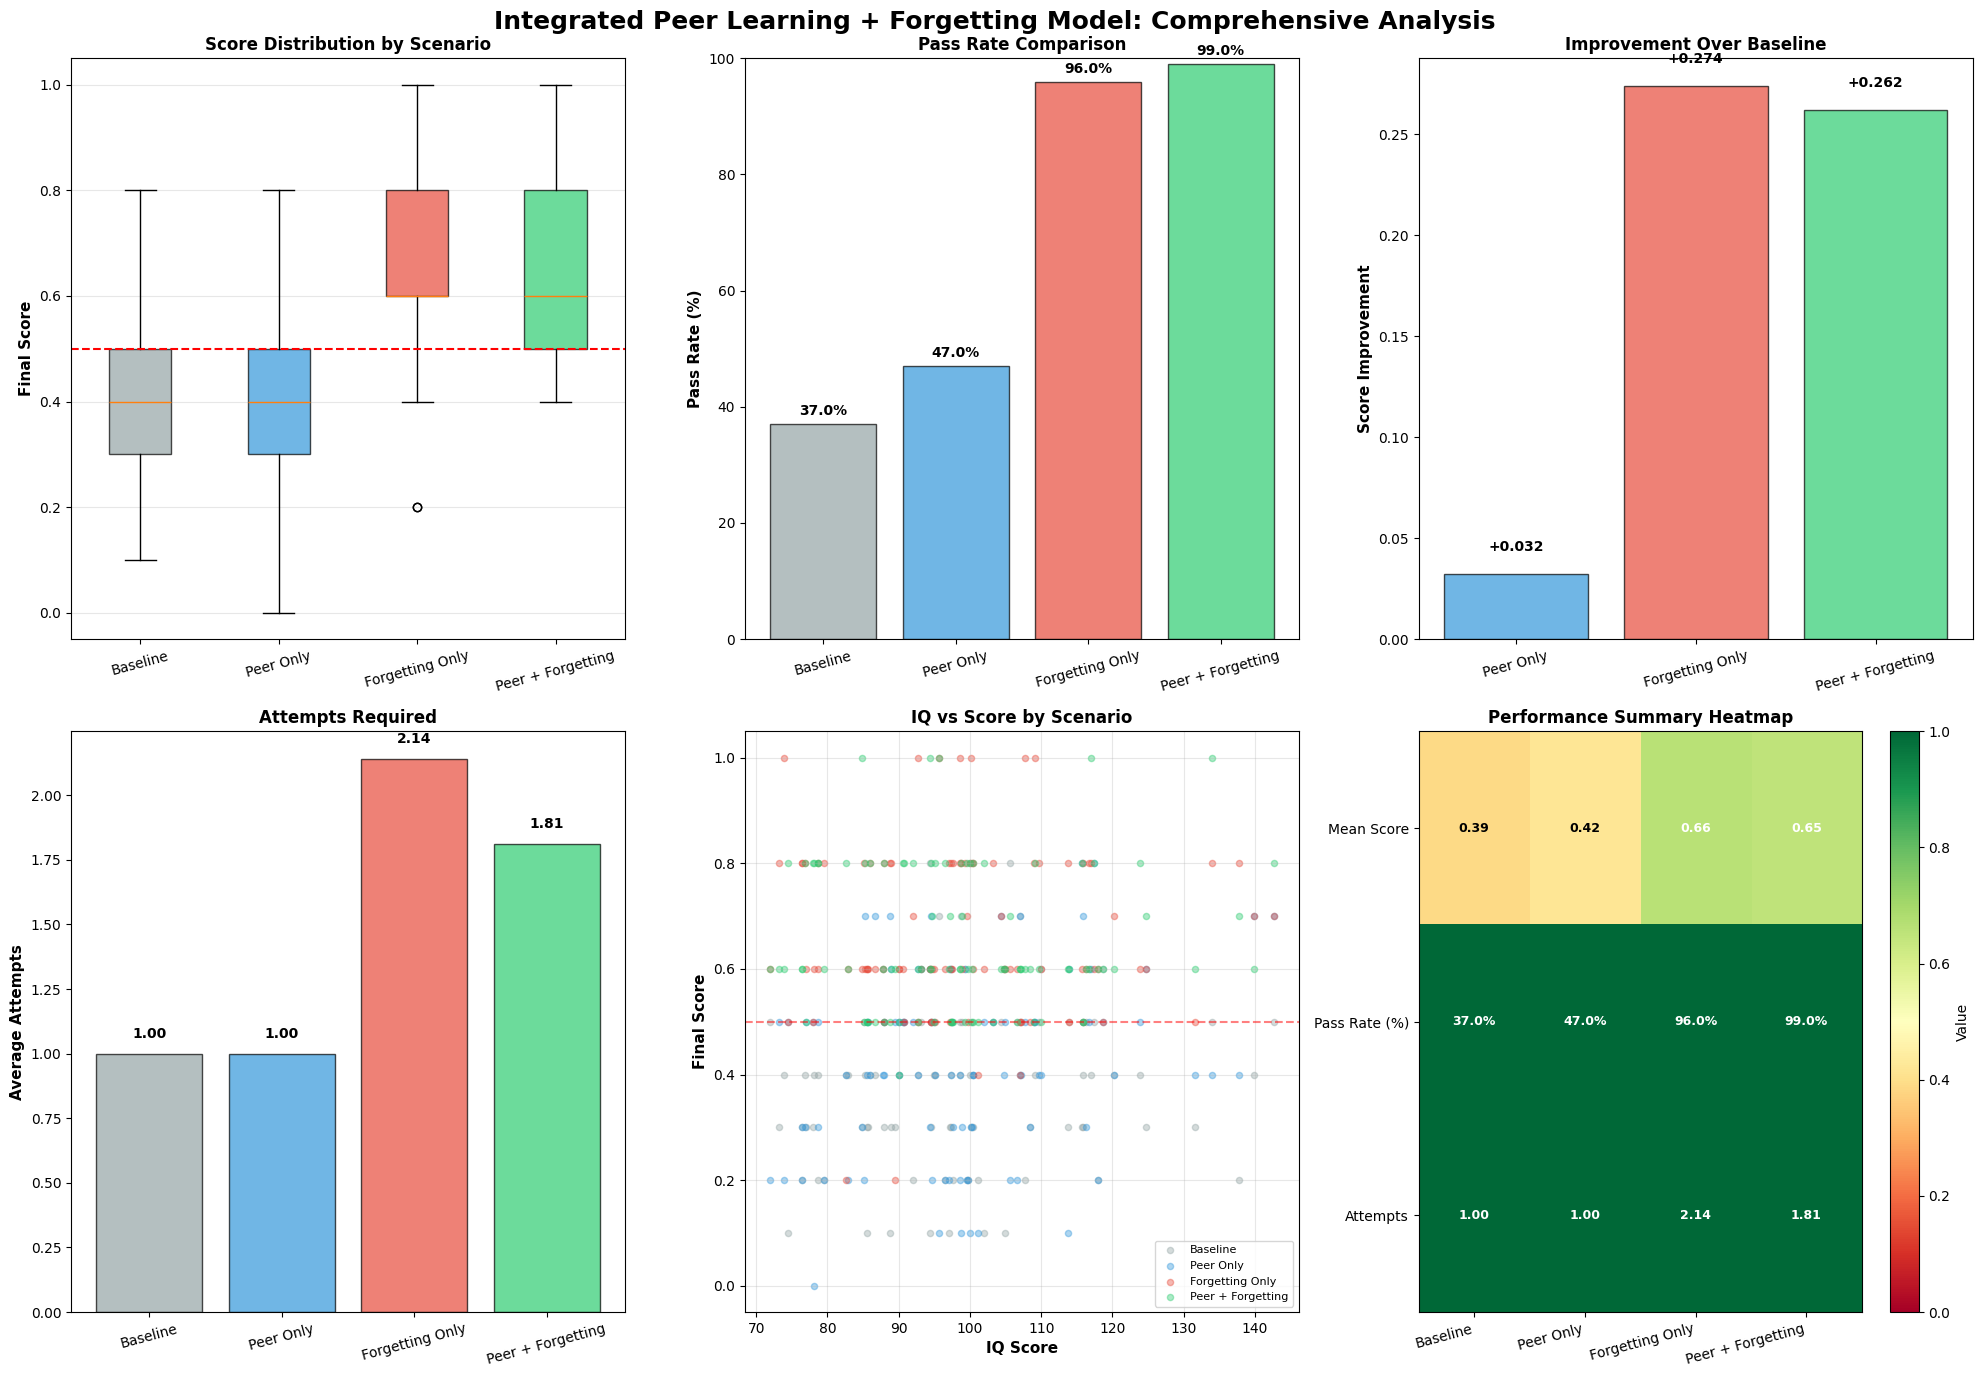

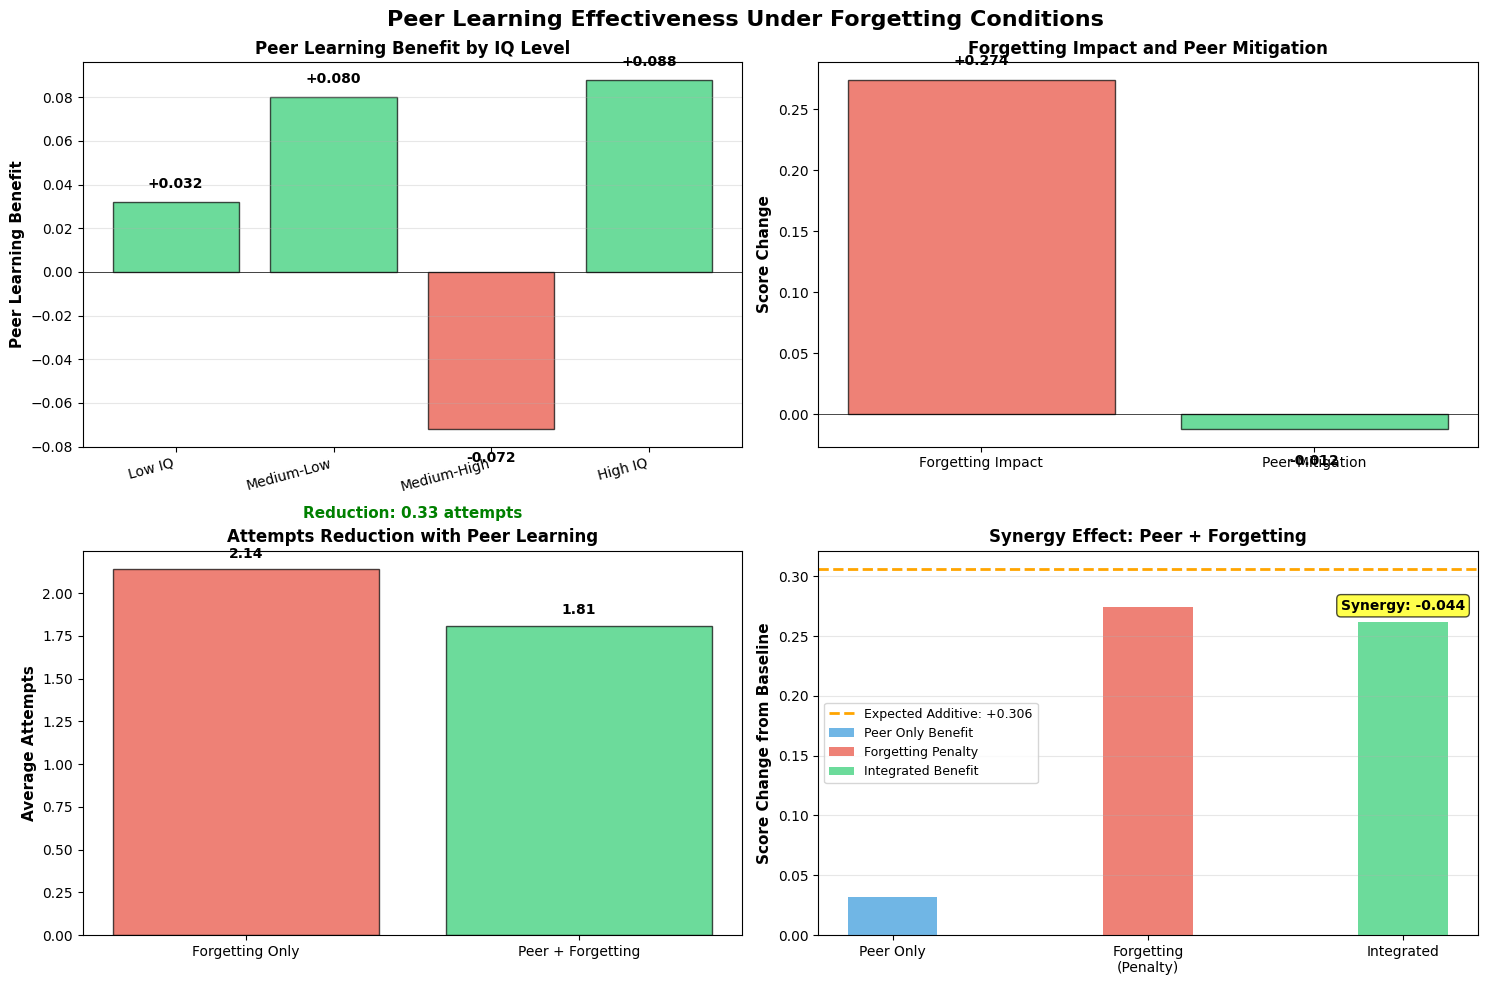

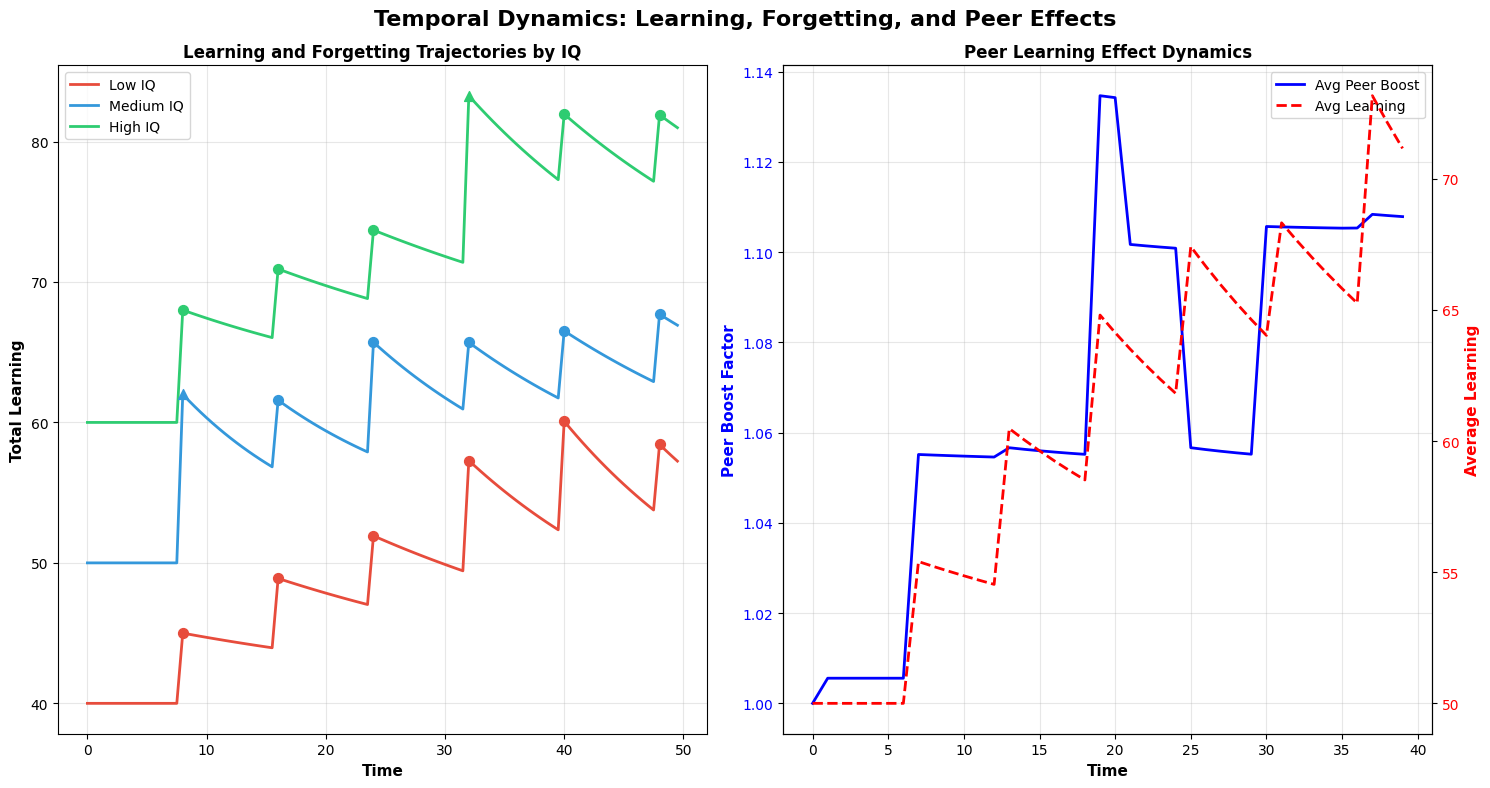


INTEGRATED PEER LEARNING + FORGETTING: STATISTICAL SUMMARY

📊 Performance Metrics by Scenario:
--------------------------------------------------------------------------------
Scenario             Mean Score      Pass Rate       Attempts     Std Dev     
--------------------------------------------------------------------------------
Baseline             0.389           37.0           % 1.00         0.156       
Peer Only            0.421           47.0           % 1.00         0.176       
Forgetting Only      0.663           96.0           % 2.14         0.159       
Peer + Forgetting    0.651           99.0           % 1.81         0.140       

🔬 Key Findings:
--------------------------------------------------------------------------------
1. Peer Learning alone improves scores by 8.2%
2. Forgetting reduces scores by -70.4%
3. Integrated approach recovers 67.4% above baseline
4. Synergy effect (extra benefit from combining): -0.044 points

🎯 IQ-Based Analysis (Peer + Forgetting sc

In [1]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from scipy.optimize import curve_fit
import copy
import warnings
warnings.filterwarnings('ignore')

# Parameters
mu, sigma = 100, 15 
students = 100
num_of_questions = 10
reinforcement_questions = 5

WEIGHT = 32
PASS_THRESHOLD = 0.5
MAX_ATTEMPTS = 5
RETENTION_THRESHOLD = 0.7

DIFFICULTY = ["easy", "medium", "hard"]
PROBABILITIES = [0.7, 0.2, 0.1]
REINFORCEMENT_PROB = [0.8, 0.2, 0.0]

IQ_QUANTILES = {
    "easy": 0.10,
    "medium": 0.50,
    "hard": 0.90
}

# Forgetting rates by difficulty
FORGETTING_RATES = {
    "easy": 0.05,
    "medium": 0.10,
    "hard": 0.15
}

# %%
# Enhanced Student Class with Peer Learning and Forgetting
class StudentWithPeerAndForgetting:
    def __init__(self, iq, initial_learning=50, student_id=None):
        self.id = student_id
        self.iq = iq
        self.base_learning = initial_learning
        self.module_learning = {}  # {module: [value, time, lambda]}
        self.peer_interactions = []  # Track peer learning events
        self.learning_history = []
        self.forgetting_adaptations = []
        
    def get_current_learning(self, t_elapsed=0):
        """Calculate current learning with forgetting"""
        total_learning = self.base_learning
        
        for module, (learned_value, learned_time, lambda_i) in self.module_learning.items():
            retention = learned_value * np.exp(-lambda_i * (t_elapsed - learned_time))
            total_learning += max(0, retention)
            
        return min(100, total_learning)
    
    def add_learning(self, module, gain, current_time, difficulty, is_peer_learning=False):
        """Add new learning with forgetting parameters"""
        lambda_i = FORGETTING_RATES[difficulty] * (1 - self.iq/200)
        
        if module not in self.module_learning:
            self.module_learning[module] = [0, current_time, lambda_i]
        
        old_value, old_time, old_lambda = self.module_learning[module]
        elapsed = current_time - old_time
        retained_old = old_value * np.exp(-old_lambda * elapsed)
        
        new_value = retained_old + gain
        self.module_learning[module] = [new_value, current_time, lambda_i]
        
        if is_peer_learning:
            self.peer_interactions.append({
                'time': current_time,
                'module': module,
                'gain': gain,
                'new_value': new_value
            })
        
        return new_value
    
    def predict_retention(self, module, time_horizon):
        """Predict retention after time_horizon"""
        if module in self.module_learning:
            value, time, lambda_i = self.module_learning[module]
            return value * np.exp(-lambda_i * time_horizon)
        return self.base_learning
    
    def update_forgetting_rate(self, module, actual_retention, predicted_retention, time_elapsed):
        """Update lambda based on prediction error"""
        if module in self.module_learning:
            _, _, old_lambda = self.module_learning[module]
            
            prediction_error = actual_retention - predicted_retention
            alpha = 0.1
            new_lambda = old_lambda - alpha * prediction_error * time_elapsed
            new_lambda = max(0.01, min(0.5, new_lambda))
            
            forgetting_gate = 1 / (1 + np.exp(-prediction_error))
            final_lambda = forgetting_gate * new_lambda + (1 - forgetting_gate) * old_lambda
            
            self.module_learning[module] = [self.module_learning[module][0], 
                                           self.module_learning[module][1], 
                                           final_lambda]
            
            self.forgetting_adaptations.append({
                'module': module,
                'time': time_elapsed,
                'prediction_error': prediction_error,
                'new_lambda': final_lambda
            })
            
            return final_lambda
        return FORGETTING_RATES.get(module, 0.1)

# %%
# Enhanced Peer Learning Network with Forgetting Awareness
class PeerLearningNetworkWithForgetting:
    def __init__(self, student_list):
        self.students = student_list
        self.network = {i: [] for i in range(len(student_list))}
        self.study_groups = []
        self.peer_learning_events = []
        
    def form_study_groups(self, n_groups=None):
        """Form groups based on IQ and current learning state"""
        if n_groups is None:
            n_groups = min(5, max(2, len(self.students)//20))
        
        features = np.array([[s.iq, s.get_current_learning()] for s in self.students])
        
        if len(self.students) < n_groups:
            n_groups = max(1, len(self.students) // 2)
        
        if n_groups <= 1 or len(self.students) <= 2:
            self.study_groups = [list(range(len(self.students)))]
        else:
            kmeans = KMeans(n_clusters=n_groups, random_state=42, n_init=10)
            groups = kmeans.fit_predict(features)
            
            self.study_groups = [[] for _ in range(max(groups)+1)]
            for idx, group_id in enumerate(groups):
                self.study_groups[group_id].append(idx)
        
        return self.study_groups
    
    def peer_learning_effect(self, student_idx, current_time):
        """Calculate learning boost from peers with forgetting awareness"""
        if not self.study_groups:
            return 1.0
            
        group_id = None
        for gid, group in enumerate(self.study_groups):
            if student_idx in group:
                group_id = gid
                break
        
        if group_id is None or len(self.study_groups[group_id]) <= 1:
            return 1.0
        
        group = self.study_groups[group_id]
        
        # Get current learning states with forgetting
        group_learning = [self.students[i].get_current_learning(current_time) for i in group]
        group_avg_learning = np.mean(group_learning)
        current_learning = self.students[student_idx].get_current_learning(current_time)
        
        # Calculate boost based on learning gap
        if current_learning < group_avg_learning:
            gap_ratio = (group_avg_learning - current_learning) / 50
            boost = 1 + 0.15 * gap_ratio
        else:
            n_lower = len([l for l in group_learning if l < current_learning])
            boost = 1 + 0.08 * min(3, n_lower)
        
        # IQ adjustment
        group_avg_iq = np.mean([self.students[i].iq for i in group])
        if self.students[student_idx].iq < group_avg_iq - 10:
            boost *= 0.95
        elif self.students[student_idx].iq > group_avg_iq + 10:
            boost *= 1.05
        
        # Forgetting-aware adjustment
        if current_time > 0:
            # Students with high forgetting rates benefit more from peer learning
            avg_lambda = np.mean([FORGETTING_RATES[d] for d in DIFFICULTY])
            student_lambda = avg_lambda * (1 - self.students[student_idx].iq/200)
            boost *= (1 + 0.1 * student_lambda)
        
        return min(1.5, max(0.85, boost))
    
    def initiate_peer_learning(self, student_idx, peer_idx, module, difficulty, current_time):
        """One student learns from another"""
        peer = self.students[peer_idx]
        student = self.students[student_idx]
        
        # Calculate how much the peer knows about this topic
        peer_knowledge = peer.get_current_learning(current_time)
        
        # Peer can only teach what they know
        teaching_gain = min(peer_knowledge * 0.1, 15)
        
        # Add learning from peer
        student.add_learning(module, teaching_gain, current_time, difficulty, is_peer_learning=True)
        
        # Record the event
        self.peer_learning_events.append({
            'time': current_time,
            'learner': student_idx,
            'teacher': peer_idx,
            'module': module,
            'gain': teaching_gain
        })
        
        return teaching_gain

# %%
# Core Functions with Integrated Features
def compute_probability_integrated(student, difficulty, t_elapsed=0, peer_boost=1.0):
    """Aᵢ(t) = (Iᵢ + Σ[ModuleLearningᵢ × e^{-λᵢ × t}]) / (Weighting × IQ Quantile) × PeerBoost"""
    iq = student.iq
    current_learning = student.get_current_learning(t_elapsed)
    quantile = IQ_QUANTILES[difficulty]
    
    A_i = (iq + current_learning) / (WEIGHT * quantile * 100)
    A_i = min(1, max(0, A_i))
    
    return min(1.0, A_i * peer_boost)

def answer_question_integrated(student, difficulty, current_time, module_id, peer_boost=1.0):
    """Answer question with forgetting and peer learning"""
    prob = compute_probability_integrated(student, difficulty, current_time, peer_boost)
    result = np.random.binomial(1, prob)
    
    if result == 1:
        if difficulty == "easy":
            gain = 2
        elif difficulty == "medium":
            gain = 5
        else:
            gain = 10
        
        student.add_learning(module_id, gain, current_time, difficulty)
    
    return result

def run_questions_integrated(student, n, probs, current_time, peer_network=None, student_idx=None):
    """Run questions with integrated peer learning and forgetting"""
    questions = list(np.random.choice(DIFFICULTY, size=n, p=probs))
    results = []
    
    for i, difficulty in enumerate(questions):
        module_id = f"module_{current_time}_{i}"
        
        # Calculate peer boost
        peer_boost = 1.0
        if peer_network and student_idx is not None:
            peer_boost = peer_network.peer_learning_effect(student_idx, current_time)
        
        result = answer_question_integrated(student, difficulty, current_time, module_id, peer_boost)
        results.append(result)
        
        # Proactive reinforcement check
        for module in list(student.module_learning.keys()):
            predicted_retention = student.predict_retention(module, time_horizon=5)
            if predicted_retention < RETENTION_THRESHOLD * student.get_current_learning():
                reinforcement_gain = 3
                student.add_learning(module, reinforcement_gain, current_time + 0.5, difficulty)
    
    return np.mean(results)

# %%
# Integrated Case Implementations
def run_case1_integrated(student_list, peer_network=None):
    """Case 1: No personalization with forgetting and peer learning"""
    scores = []
    for idx, student in enumerate(student_list):
        peer_network_local = peer_network if peer_network else None
        peer_idx = idx if peer_network_local else None
        score = run_questions_integrated(student, num_of_questions, PROBABILITIES, 0, 
                                        peer_network_local, peer_idx)
        scores.append(score)
    return scores

def run_module_case2_integrated(student, current_time, peer_network=None, student_idx=None):
    """Case 2: Reinforcement with forgetting and peer learning"""
    score = run_questions_integrated(student, num_of_questions, PROBABILITIES, current_time,
                                    peer_network, student_idx)
    attempts = 1
    
    while score < PASS_THRESHOLD and attempts < MAX_ATTEMPTS:
        time_elapsed = attempts * 2
        score = run_questions_integrated(student, reinforcement_questions, REINFORCEMENT_PROB,
                                        current_time + time_elapsed, peer_network, student_idx)
        attempts += 1
    
    return score, attempts

def run_case2_integrated(student_list, peer_network=None):
    """Case 2 integrated"""
    scores, attempts = [], []
    for idx, student in enumerate(student_list):
        peer_idx = idx if peer_network else None
        s, a = run_module_case2_integrated(student, 0, peer_network, peer_idx)
        scores.append(s)
        attempts.append(a)
    return scores, attempts

def teacher_intervention_integrated(student):
    """Teacher adds 15 points to base learning"""
    student.base_learning += 15

def run_case3_integrated(student_list, peer_network=None):
    """Case 3: Teacher support with forgetting and peer learning"""
    results = []
    
    # Step 1: Run Case 2
    for idx, student in enumerate(student_list):
        peer_idx = idx if peer_network else None
        score, attempts = run_module_case2_integrated(student, 0, peer_network, peer_idx)
        results.append([student, score, attempts, idx])
    
    # Step 2: Select FAILED students only
    failed_students = [r for r in results if r[1] < PASS_THRESHOLD]
    
    # Step 3: Apply teacher intervention
    for student, _, _, _ in failed_students:
        teacher_intervention_integrated(student)
    
    # Step 4: Re-test all students
    final_scores, final_attempts = [], []
    for student, _, attempts, idx in results:
        time_elapsed = attempts
        peer_idx = idx if peer_network else None
        score = run_questions_integrated(student, reinforcement_questions, REINFORCEMENT_PROB,
                                        time_elapsed, peer_network, peer_idx)
        final_scores.append(score)
        final_attempts.append(attempts + 1)
    
    return final_scores, final_attempts

# %%
# Main Comparison Function
def run_integrated_comparison(n_students=100):
    """Compare all four scenarios"""
    
    # Generate base students
    base_students = [StudentWithPeerAndForgetting(iq=np.random.normal(mu, sigma), 
                                                    initial_learning=50, 
                                                    student_id=i) 
                     for i in range(n_students)]
    
    results = {}
    
    # Scenario 1: No Peer, No Forgetting (Baseline)
    students_sc1 = copy.deepcopy(base_students)
    scores_sc1 = run_case1_integrated(students_sc1, peer_network=None)
    results['Baseline'] = {'scores': scores_sc1, 'attempts': [1]*n_students}
    
    # Scenario 2: Peer Learning Only
    students_sc2 = copy.deepcopy(base_students)
    peer_network_sc2 = PeerLearningNetworkWithForgetting(students_sc2)
    peer_network_sc2.form_study_groups()
    scores_sc2 = run_case1_integrated(students_sc2, peer_network_sc2)
    results['Peer Only'] = {'scores': scores_sc2, 'attempts': [1]*n_students}
    
    # Scenario 3: Forgetting Only (No Peer)
    students_sc3 = copy.deepcopy(base_students)
    scores_sc3, attempts_sc3 = run_case2_integrated(students_sc3, peer_network=None)
    results['Forgetting Only'] = {'scores': scores_sc3, 'attempts': attempts_sc3}
    
    # Scenario 4: Peer + Forgetting (Full Integration)
    students_sc4 = copy.deepcopy(base_students)
    peer_network_sc4 = PeerLearningNetworkWithForgetting(students_sc4)
    peer_network_sc4.form_study_groups()
    scores_sc4, attempts_sc4 = run_case2_integrated(students_sc4, peer_network_sc4)
    results['Peer + Forgetting'] = {'scores': scores_sc4, 'attempts': attempts_sc4}
    
    # Create DataFrames
    dfs = {}
    for scenario_name, data in results.items():
        dfs[scenario_name] = pd.DataFrame({
            'iq': [s.iq for s in base_students],
            'final_score': data['scores'],
            'attempts': data['attempts'],
            'passed': [1 if s >= PASS_THRESHOLD else 0 for s in data['scores']],
            'scenario': scenario_name
        })
    
    return dfs, results

# %%
# Run the integrated comparison
print("="*80)
print("INTEGRATED PEER LEARNING + FORGETTING MODEL SIMULATION")
print("="*80)
print("\nComparing 4 scenarios:")
print("  1. Baseline (No peer learning, no forgetting)")
print("  2. Peer Learning Only")
print("  3. Forgetting Only")
print("  4. Peer + Forgetting (Full Integration)")
print("-"*80)

dfs, results = run_integrated_comparison(100)

# %%
# Visualization 1: Comprehensive Comparison Dashboard
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Integrated Peer Learning + Forgetting Model: Comprehensive Analysis', 
             fontsize=18, fontweight='bold')

# 1. Score Distributions
ax1 = plt.subplot(2, 3, 1)
scenario_names = list(dfs.keys())
score_data = [dfs[s]['final_score'] for s in scenario_names]
bp = ax1.boxplot(score_data, labels=scenario_names, patch_artist=True)
colors = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('Final Score', fontsize=11, fontweight='bold')
ax1.set_title('Score Distribution by Scenario', fontsize=12, fontweight='bold')
ax1.axhline(y=PASS_THRESHOLD, color='red', linestyle='--', linewidth=1.5)
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=15)

# 2. Pass Rates
ax2 = plt.subplot(2, 3, 2)
pass_rates = [dfs[s]['passed'].mean() * 100 for s in scenario_names]
bars = ax2.bar(scenario_names, pass_rates, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Pass Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Pass Rate Comparison', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 100])
for bar, rate in zip(bars, pass_rates):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

# 3. Improvement Over Baseline
ax3 = plt.subplot(2, 3, 3)
baseline_mean = dfs['Baseline']['final_score'].mean()
improvements = [(dfs[s]['final_score'].mean() - baseline_mean) for s in scenario_names[1:]]
improvement_colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax3.bar(scenario_names[1:], improvements, color=improvement_colors, alpha=0.7, edgecolor='black')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_ylabel('Score Improvement', fontsize=11, fontweight='bold')
ax3.set_title('Improvement Over Baseline', fontsize=12, fontweight='bold')
for bar, imp in zip(bars, improvements):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.01 if imp >= 0 else -0.03),
             f'{imp:+.3f}', ha='center', va='bottom' if imp >= 0 else 'top', fontweight='bold')
ax3.tick_params(axis='x', rotation=15)

# 4. Attempts Required
ax4 = plt.subplot(2, 3, 4)
attempts_data = [dfs[s]['attempts'].mean() for s in scenario_names]
bars = ax4.bar(scenario_names, attempts_data, color=colors, alpha=0.7, edgecolor='black')
ax4.set_ylabel('Average Attempts', fontsize=11, fontweight='bold')
ax4.set_title('Attempts Required', fontsize=12, fontweight='bold')
for bar, att in zip(bars, attempts_data):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{att:.2f}', ha='center', va='bottom', fontweight='bold')
ax4.tick_params(axis='x', rotation=15)

# 5. IQ vs Score Scatter
ax5 = plt.subplot(2, 3, 5)
for scenario, color in zip(scenario_names, colors):
    df = dfs[scenario]
    ax5.scatter(df['iq'], df['final_score'], alpha=0.4, s=20, 
                label=scenario, color=color)
ax5.set_xlabel('IQ Score', fontsize=11, fontweight='bold')
ax5.set_ylabel('Final Score', fontsize=11, fontweight='bold')
ax5.set_title('IQ vs Score by Scenario', fontsize=12, fontweight='bold')
ax5.axhline(y=PASS_THRESHOLD, color='red', linestyle='--', alpha=0.5)
ax5.legend(loc='best', fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. Summary Heatmap
ax6 = plt.subplot(2, 3, 6)
summary_matrix = np.array([
    [dfs[s]['final_score'].mean() for s in scenario_names],
    [dfs[s]['passed'].mean() * 100 for s in scenario_names],
    [dfs[s]['attempts'].mean() for s in scenario_names]
])
im = ax6.imshow(summary_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax6.set_xticks(range(len(scenario_names)))
ax6.set_yticks(range(3))
ax6.set_xticklabels(scenario_names, rotation=15, ha='right')
ax6.set_yticklabels(['Mean Score', 'Pass Rate (%)', 'Attempts'])
ax6.set_title('Performance Summary Heatmap', fontsize=12, fontweight='bold')

for i in range(3):
    for j in range(len(scenario_names)):
        value = summary_matrix[i, j]
        text = ax6.text(j, i, f'{value:.2f}' if i != 1 else f'{value:.1f}%',
                       ha="center", va="center", 
                       color="white" if value > 0.5 else "black",
                       fontweight='bold', fontsize=9)

plt.colorbar(im, ax=ax6, label='Value')
plt.tight_layout()
plt.show()

# %%
# Visualization 2: Peer Learning Effectiveness with Forgetting (CORRECTED)
fig2 = plt.figure(figsize=(15, 10))
fig2.suptitle('Peer Learning Effectiveness Under Forgetting Conditions', fontsize=16, fontweight='bold')

# Analyze peer learning benefits across IQ levels
df_peer_only = dfs['Peer Only']
df_forgetting_only = dfs['Forgetting Only']
df_integrated = dfs['Peer + Forgetting']
df_baseline = dfs['Baseline']  # FIXED: Define df_baseline

# Create IQ segments
iq_segments = pd.qcut(df_baseline['iq'], q=4, labels=['Low IQ', 'Medium-Low', 'Medium-High', 'High IQ'])

# 1. Peer benefit by IQ
ax1 = plt.subplot(2, 2, 1)
peer_benefit = []
for segment in iq_segments.cat.categories:
    mask = iq_segments == segment
    baseline_seg = df_baseline[mask]['final_score'].mean()
    peer_seg = df_peer_only[mask]['final_score'].mean()
    benefit = peer_seg - baseline_seg
    peer_benefit.append(benefit)

x = np.arange(len(iq_segments.cat.categories))
bars = ax1.bar(x, peer_benefit, color=['#2ecc71' if b > 0 else '#e74c3c' for b in peer_benefit], 
               alpha=0.7, edgecolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(iq_segments.cat.categories, rotation=15, ha='right')
ax1.set_ylabel('Peer Learning Benefit', fontsize=11, fontweight='bold')
ax1.set_title('Peer Learning Benefit by IQ Level', fontsize=12, fontweight='bold')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.grid(True, alpha=0.3, axis='y')

for bar, benefit in zip(bars, peer_benefit):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.005 if benefit >= 0 else -0.01),
             f'{benefit:+.3f}', ha='center', va='bottom' if benefit >= 0 else 'top', fontweight='bold')

# 2. Forgetting mitigation with peer learning
ax2 = plt.subplot(2, 2, 2)
forgetting_impact = df_forgetting_only['final_score'].mean() - df_baseline['final_score'].mean()
mitigation = df_integrated['final_score'].mean() - df_forgetting_only['final_score'].mean()

ax2.bar(['Forgetting Impact', 'Peer Mitigation'], 
        [forgetting_impact, mitigation],
        color=['#e74c3c', '#2ecc71'], alpha=0.7, edgecolor='black')
ax2.set_ylabel('Score Change', fontsize=11, fontweight='bold')
ax2.set_title('Forgetting Impact and Peer Mitigation', fontsize=12, fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for bar, val in zip(ax2.patches, [forgetting_impact, mitigation]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.01 if val >= 0 else -0.02),
             f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top', fontweight='bold')

# 3. Attempts reduction with integrated approach
ax3 = plt.subplot(2, 2, 3)
attempts_comparison = [
    df_forgetting_only['attempts'].mean(),
    df_integrated['attempts'].mean()
]
bars = ax3.bar(['Forgetting Only', 'Peer + Forgetting'], attempts_comparison,
               color=['#e74c3c', '#2ecc71'], alpha=0.7, edgecolor='black')
ax3.set_ylabel('Average Attempts', fontsize=11, fontweight='bold')
ax3.set_title('Attempts Reduction with Peer Learning', fontsize=12, fontweight='bold')
reduction = attempts_comparison[0] - attempts_comparison[1]
for bar, att in zip(bars, attempts_comparison):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{att:.2f}', ha='center', va='bottom', fontweight='bold')
ax3.text(0.5, max(attempts_comparison) + 0.3, f'Reduction: {reduction:.2f} attempts',
         ha='center', fontweight='bold', fontsize=11, color='green')

# 4. Synergy effect
ax4 = plt.subplot(2, 2, 4)
peer_only_benefit = df_peer_only['final_score'].mean() - df_baseline['final_score'].mean()
forgetting_penalty = df_baseline['final_score'].mean() - df_forgetting_only['final_score'].mean()
integrated_benefit = df_integrated['final_score'].mean() - df_baseline['final_score'].mean()
expected_additive = peer_only_benefit - forgetting_penalty
synergy = integrated_benefit - expected_additive

x = np.arange(3)
width = 0.35
bars1 = ax4.bar(x[0], peer_only_benefit, width, label='Peer Only Benefit', color='#3498db', alpha=0.7)
bars2 = ax4.bar(x[1], -forgetting_penalty, width, label='Forgetting Penalty', color='#e74c3c', alpha=0.7)
bars3 = ax4.bar(x[2], integrated_benefit, width, label='Integrated Benefit', color='#2ecc71', alpha=0.7)

# Add additive expectation line
ax4.axhline(y=expected_additive, color='orange', linestyle='--', linewidth=2, 
            label=f'Expected Additive: {expected_additive:+.3f}')
ax4.set_xticks(x)
ax4.set_xticklabels(['Peer Only', 'Forgetting\n(Penalty)', 'Integrated'])
ax4.set_ylabel('Score Change from Baseline', fontsize=11, fontweight='bold')
ax4.set_title('Synergy Effect: Peer + Forgetting', fontsize=12, fontweight='bold')
ax4.legend(loc='best', fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

# Annotate synergy
ax4.text(2, integrated_benefit + 0.01, f'Synergy: {synergy:+.3f}',
         ha='center', fontweight='bold', fontsize=10, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.show()
# %%
# Visualization 3: Temporal Dynamics
fig3 = plt.figure(figsize=(15, 8))
fig3.suptitle('Temporal Dynamics: Learning, Forgetting, and Peer Effects', fontsize=16, fontweight='bold')

# Simulate a representative student over time
np.random.seed(42)
representative_students = {
    'Low IQ': StudentWithPeerAndForgetting(iq=75, initial_learning=40),
    'Medium IQ': StudentWithPeerAndForgetting(iq=100, initial_learning=50),
    'High IQ': StudentWithPeerAndForgetting(iq=125, initial_learning=60)
}

# Simulate learning trajectory
time_points = np.arange(0, 50, 0.5)
learning_trajectories = {k: [] for k in representative_students.keys()}
learning_events = []

for t in time_points:
    for label, student in representative_students.items():
        # Sporadic learning events
        if t % 8 < 0.5 and t > 0:
            difficulty = np.random.choice(DIFFICULTY, p=PROBABILITIES)
            gain = {'easy': 5, 'medium': 8, 'hard': 12}[difficulty]
            student.add_learning(f"event_{int(t)}", gain, t, difficulty)
            learning_events.append((label, t, difficulty, gain))
        
        learning_trajectories[label].append(student.get_current_learning(t))

# 1. Learning trajectories
ax1 = plt.subplot(1, 2, 1)
colors_plot = {'Low IQ': '#e74c3c', 'Medium IQ': '#3498db', 'High IQ': '#2ecc71'}
for label, trajectory in learning_trajectories.items():
    ax1.plot(time_points, trajectory, linewidth=2, label=label, color=colors_plot[label])

ax1.set_xlabel('Time', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total Learning', fontsize=11, fontweight='bold')
ax1.set_title('Learning and Forgetting Trajectories by IQ', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Mark learning events
for label, t, difficulty, gain in learning_events:
    idx = np.where(time_points == t)[0]
    if len(idx) > 0:
        ax1.scatter(t, learning_trajectories[label][idx[0]], 
                   color=colors_plot[label], s=50, zorder=5, 
                   marker='^' if difficulty == 'hard' else 'o')

# 2. Peer learning effect over time
ax2 = plt.subplot(1, 2, 2)
# Simulate a group of students with peer learning
group_students = [StudentWithPeerAndForgetting(iq=np.random.normal(100, 15), initial_learning=50) 
                  for _ in range(5)]
peer_network = PeerLearningNetworkWithForgetting(group_students)
peer_network.form_study_groups(n_groups=1)

time_peers = np.arange(0, 40, 1)
peer_boosts = []
avg_learning = []

for t in time_peers:
    # Calculate peer boosts for each student
    boosts = [peer_network.peer_learning_effect(i, t) for i in range(len(group_students))]
    peer_boosts.append(np.mean(boosts))
    
    # Get average learning
    avg_learn = np.mean([s.get_current_learning(t) for s in group_students])
    avg_learning.append(avg_learn)
    
    # Occasional learning event
    if t % 6 < 1 and t > 0:
        for s in group_students:
            difficulty = np.random.choice(DIFFICULTY, p=PROBABILITIES)
            gain = {'easy': 5, 'medium': 8, 'hard': 12}[difficulty]
            s.add_learning(f"group_event_{int(t)}", gain, t, difficulty)

ax2_twin = ax2.twinx()
ax2.plot(time_peers, peer_boosts, 'b-', linewidth=2, label='Avg Peer Boost')
ax2.set_xlabel('Time', fontsize=11, fontweight='bold')
ax2.set_ylabel('Peer Boost Factor', fontsize=11, fontweight='bold', color='b')
ax2.tick_params(axis='y', labelcolor='b')

ax2_twin.plot(time_peers, avg_learning, 'r--', linewidth=2, label='Avg Learning')
ax2_twin.set_ylabel('Average Learning', fontsize=11, fontweight='bold', color='r')
ax2_twin.tick_params(axis='y', labelcolor='r')

ax2.set_title('Peer Learning Effect Dynamics', fontsize=12, fontweight='bold')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# Statistical Summary
print("\n" + "="*80)
print("INTEGRATED PEER LEARNING + FORGETTING: STATISTICAL SUMMARY")
print("="*80)

print("\n📊 Performance Metrics by Scenario:")
print("-" * 80)
print(f"{'Scenario':<20} {'Mean Score':<15} {'Pass Rate':<15} {'Attempts':<12} {'Std Dev':<12}")
print("-" * 80)

for scenario in scenario_names:
    df = dfs[scenario]
    print(f"{scenario:<20} {df['final_score'].mean():<15.3f} "
          f"{df['passed'].mean()*100:<15.1f}% "
          f"{df['attempts'].mean():<12.2f} "
          f"{df['final_score'].std():<12.3f}")

print("\n🔬 Key Findings:")
print("-" * 80)

# Calculate key metrics
baseline_mean = dfs['Baseline']['final_score'].mean()
peer_improvement = (dfs['Peer Only']['final_score'].mean() - baseline_mean) / baseline_mean * 100
forgetting_decline = (baseline_mean - dfs['Forgetting Only']['final_score'].mean()) / baseline_mean * 100
integrated_improvement = (dfs['Peer + Forgetting']['final_score'].mean() - baseline_mean) / baseline_mean * 100
synergy = (dfs['Peer + Forgetting']['final_score'].mean() - dfs['Forgetting Only']['final_score'].mean()) - \
          (dfs['Peer Only']['final_score'].mean() - baseline_mean)

print(f"1. Peer Learning alone improves scores by {peer_improvement:.1f}%")
print(f"2. Forgetting reduces scores by {forgetting_decline:.1f}%")
print(f"3. Integrated approach recovers {integrated_improvement:.1f}% above baseline")
print(f"4. Synergy effect (extra benefit from combining): {synergy:+.3f} points")

# IQ-based analysis
print(f"\n🎯 IQ-Based Analysis (Peer + Forgetting scenario):")
for i, segment in enumerate(iq_segments.cat.categories):
    mask = iq_segments == segment
    integrated_mean = dfs['Peer + Forgetting'][mask]['final_score'].mean()
    forgetting_mean = dfs['Forgetting Only'][mask]['final_score'].mean()
    print(f"   • {segment}: Integrated {integrated_mean:.3f} vs Forgetting Only {forgetting_mean:.3f} "
          f"(Benefit: {integrated_mean - forgetting_mean:+.3f})")


# %%
# Export results
for scenario, df in dfs.items():
    filename = f"integrated_{scenario.lower().replace(' ', '_').replace('+', 'plus')}.csv"
    df.to_csv(filename, index=False)
    print(f"✓ Saved {filename}")

print("\n✅ All results exported successfully!")
print("\n" + "="*80)